In [20]:
# Importing library
################################################################################

import tensorflow as tf
from tensorflow import config
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, optimizers, initializers
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.layers import LeakyReLU, BatchNormalization
import numpy as np
import os
import numpy.ma as ma
from sklearn.utils import shuffle
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, Activation, Flatten, MaxPooling2D, AveragePooling2D

from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.layers import Dense, Dropout, Activation, Flatten
import time
import numpy as np
from tensorflow.keras.initializers import random_normal, random_uniform, glorot_normal, glorot_uniform, HeNormal, HeUniform, Zeros
from sklearn.model_selection import train_test_split
#from google.colab import files
from netCDF4 import Dataset
import math
from tensorflow.keras import regularizers
from scipy import signal
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import grangercausalitytests

In [21]:
#!pip install basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='seismic')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



In [22]:
# Loading CMIP6 training data
###############################################################################

trX=np.load('18_month_lead_data/CMIP6_MME_Input.npy', allow_pickle=True)
trY=np.load('18_month_lead_data/CMIP6_MME_Output_yearmean.npy', allow_pickle=True)

trX=np.swapaxes(trX, 1, 2)

arr=[]
for i in range(6390):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(trX[i,:,:,0])
    input_file[1,:,:]=np.flipud(trX[i,:,:,1])
    input_file[2,:,:]=np.flipud(trX[i,:,:,2])
    
    arr.append(input_file)

trX=np.array(arr)
trX=np.swapaxes(trX,1,3)


trainX, trainY = shuffle(trX, trY, random_state=2)

In [18]:
trY.shape

(6390, 1)

In [19]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest

mutual_info = np.zeros((trainX.shape[1], trainX.shape[2]))

for j in range(trainX.shape[1]):
    for k in range(trainX.shape[2]):
        mutual_info[j,k] = mutual_info_regression(trX[:, j, k,:].mean(axis=-1).reshape(-1,1), trY.reshape(-1,1))

/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was 

KeyboardInterrupt: 

In [ ]:
percentile_80 = np.percentile(mutual_info, 80)
print(percentile_80)

0.009557026221225229


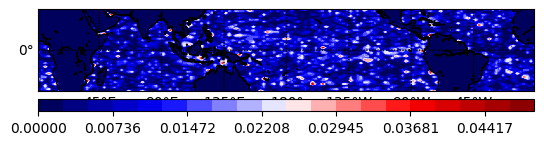

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_map(lon_sst, lat_sst, np.flipud(mutual_info.T), 'mutual_info.png')

In [ ]:
np.save('mutual_info_mask_80%.npy', np.flipud(mutual_info.T)>percentile_80)

In [ ]:
lat_sst = data3.variables['lat'][:]
lon_sst = data3.variables['lon'][:]

Variance explained — EOF1: 14.5%, EOF2: 6.1%, EOF3: 3.2%


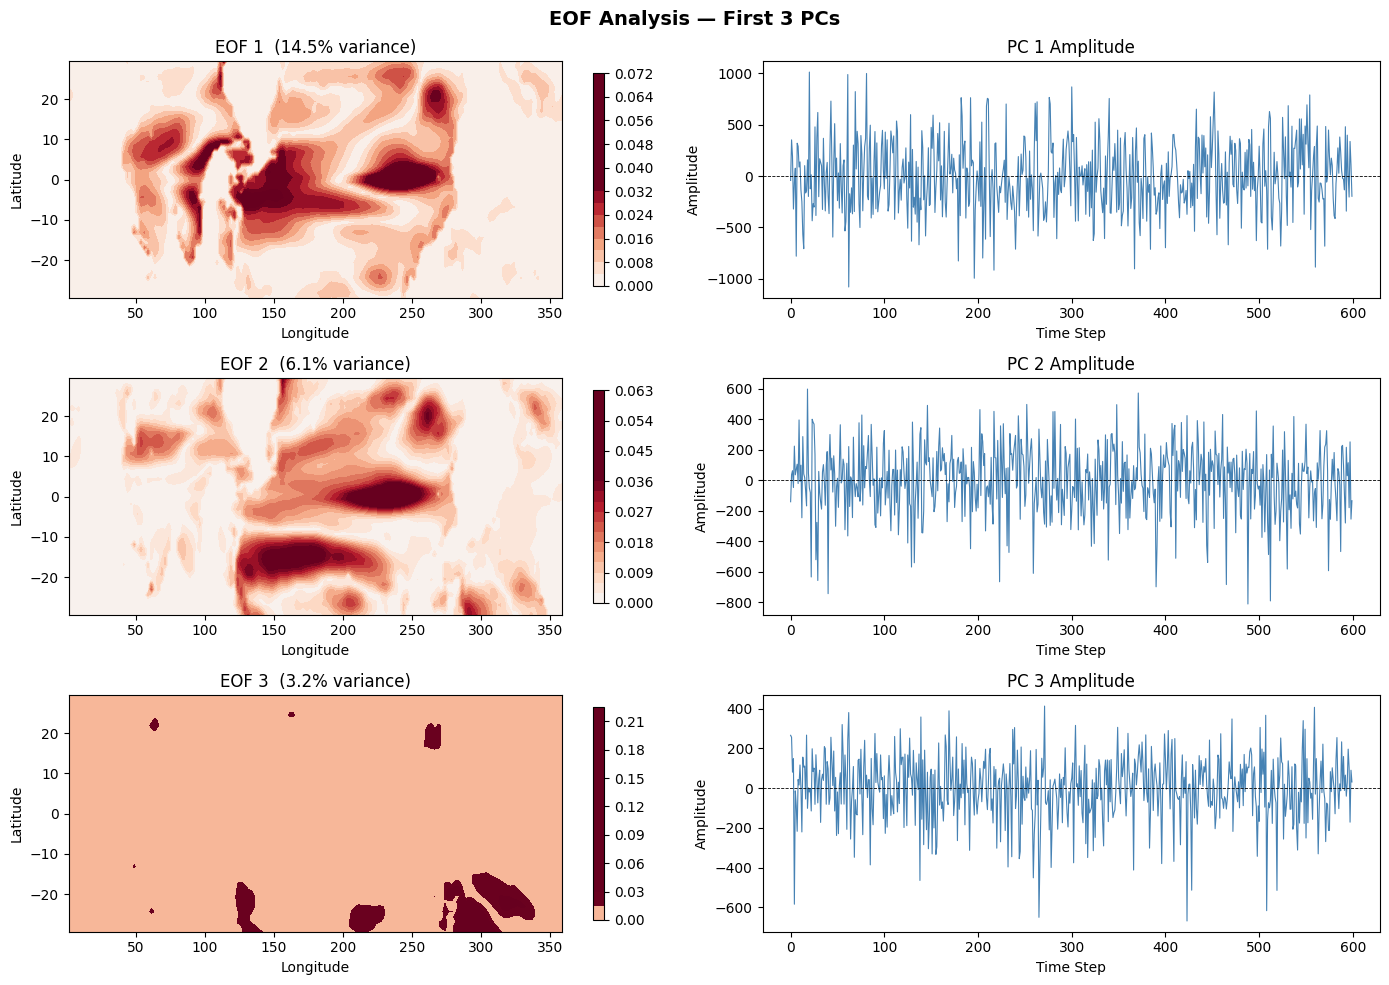

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from eofs.standard import Eof

# ── Data (replace with your array) ──────────────────────────
np.random.seed(42)
data = trainX.mean(axis=-1)[:600]  # (time, lon, lat)
lon  = lon_sst#np.linspace(0, 357.5, 144)
lat  = lat_sst#np.linspace(-90, 87.5, 48)
LON, LAT = np.meshgrid(lon, lat, indexing='ij')

# ── EOF solver ───────────────────────────────────────────────
solver  = Eof(data)                           # demeans automatically
EOFs    = abs(solver.eofs(neofs=3))                # (3, 144, 48)
PCs     = solver.pcs(npcs=3)                  # (600, 3)
var     = solver.varianceFraction(neigs=3) * 100   # % variance

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("EOF Analysis — First 3 PCs", fontsize=14, fontweight='bold')

for i in range(3):
    # Spatial pattern
    ax = axes[i, 0]
    vmax = np.percentile(np.abs(EOFs[i]), 98)
    cf = ax.contourf(LON, LAT, EOFs[i], levels=21, cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax)
    ax.set_title(f'EOF {i+1}  ({var[i]:.1f}% variance)')
    ax.set_xlabel('Longitude');  ax.set_ylabel('Latitude')
    fig.colorbar(cf, ax=ax, shrink=0.9)

    # PC time series
    ax = axes[i, 1]
    ax.plot(PCs[:, i], linewidth=0.8, color='steelblue')
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.set_title(f'PC {i+1} Amplitude')
    ax.set_xlabel('Time Step');  ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig('eof_result.png', dpi=150, bbox_inches='tight')
print("Variance explained —", ", ".join([f"EOF{i+1}: {var[i]:.1f}%" for i in range(3)]))


In [ ]:
mask_list=[]
# Get the top 90% threshold for EOFs.swapaxes(1, 2)[0]
for i in range(len(EOFs)):
    eof_data = EOFs.swapaxes(1, 2)[i]
    threshold = np.percentile(eof_data, 90)
    mask_list.append(eof_data >= threshold)

mask_list = np.array(mask_list)
mask_list.shape

(3, 48, 144)

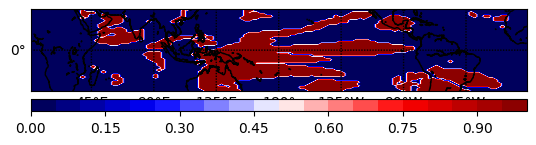

<Figure size 640x480 with 0 Axes>

In [ ]:
# Boolean add the mask_list to axis=0
mask_combined = np.any(mask_list, axis=0)
np.save('EOF_combined_mask.npy', mask_combined)
plot_map(lon_sst, lat_sst, mask_combined, 'EOF_combined_mask.png')

In [ ]:
EOF_combined_mask = np.load('EOF_combined_mask.npy')

/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


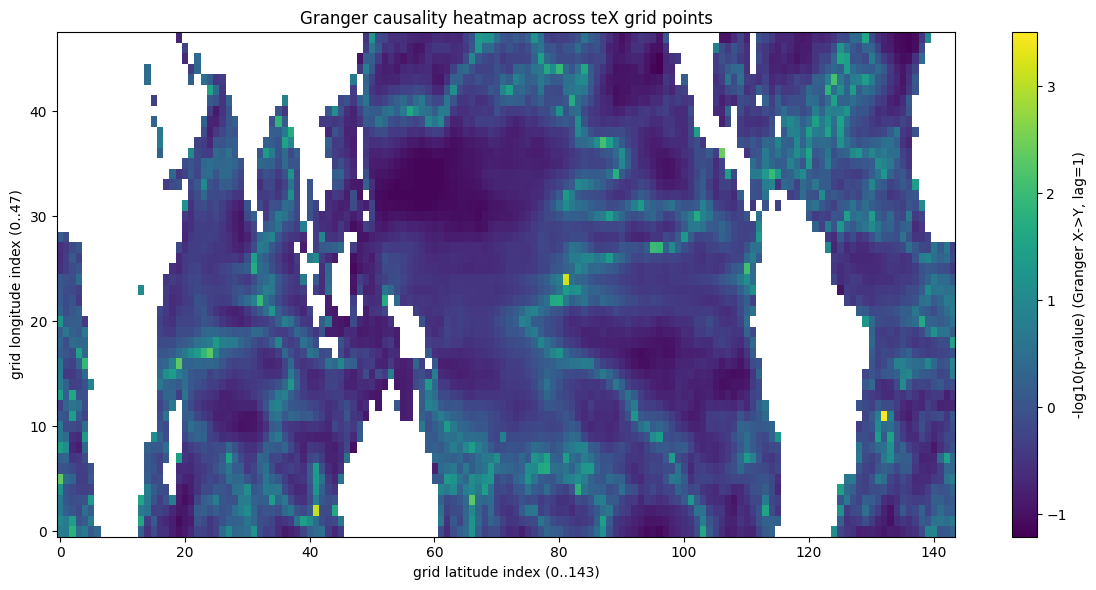

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

import matplotlib.pyplot as plt

n = 6390
X = trX[:n]             # shape (31, 144, 48, 3)
Y = np.asarray(trY[:n], dtype=np.float64)  # shape (31,)

maxlag = 1
# pvals = np.full((144, 48), np.nan, dtype=np.float64)
# fstats = np.full((144, 48), np.nan, dtype=np.float64)
linear_gc_scores = np.full((144, 48), np.nan, dtype=np.float64)
for i in range(144):
    for j in range(48):
        x = X[:, i, j, :].mean(axis=1)  # combine 3 channels
        data = np.column_stack([Y, x])  # Y is target, x is driver
        try:
            test_result = grangercausalitytests(data, maxlag=maxlag, verbose=False)
            p_values = [test_result[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag + 1)]  # Extract p-values
            linear_gc_scores[i,j] = -np.log(min(p_values))  # Use -log(p) to rank (lower p → higher GC)
        except Exception:
            pass


causality_strength = -np.log10(linear_gc_scores)
causality_strength[np.isneginf(causality_strength)] = np.nan
causality_strength[np.isinf(causality_strength)] = np.nan

plt.figure(figsize=(12, 6))
plt.imshow(causality_strength.T, origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(label="-log10(p-value) (Granger X->Y, lag=1)")
plt.title("Granger causality heatmap across teX grid points")
plt.xlabel("grid latitude index (0..143)")
plt.ylabel("grid longitude index (0..47)")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
significance_mask = np.load('significance_mask_SODA.npy')
strong_idx = np.argwhere(significance_mask ==1)
#strong_values = causality_strength[causality_strength > 3]

# print("Number of locations:", strong_idx.shape[0])
# print("Locations (i, j):", strong_idx)
# print("Strength values:", strong_values)

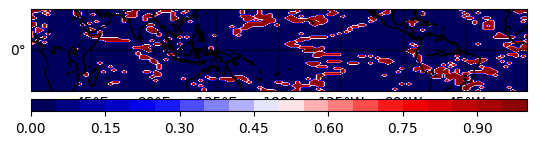

<Figure size 640x480 with 0 Axes>

In [ ]:
lat_sst = data3.variables['lat'][:]
lon_sst = data3.variables['lon'][:]
plot_map(lon_sst, lat_sst, significance_mask.T, 'significance_mask_SODA.png')

In [ ]:
MI_mask= np.load('mutual_info_mask_80%.npy')

In [ ]:
import numpy as np
# apply significance mask to each sample in trX
# trX shape is (n_samples, 144, 48, 3)
# significance_mask shape is (144, 48), boolean
mask = np.array(MI_mask.T, dtype=np.float32)  # from cell 5/18
mask3 = mask[None, :, :, None]  # broadcast to (1,144,48,1)

trX_masked = trX * mask3  # zeros out non-significant grid cells across channels

# optional: verify that non-significant cells are zero
#assert np.all(trX_masked[:, EOF_combined_mask == False, :] == 0)

# use trX_masked for modeling / feature extraction going forward
#trainX = trX_masked

trainX, trainY = shuffle(trX_masked, trY, random_state=2)

trainX.shape, trainY.shape

((6390, 144, 48, 3), (6390, 1))

In [ ]:
# feature_dataset=[]
# for len in range(trX.shape[0]):
#     feature_values=[]
#     for ch in range(3):
#         f = []
#         for loc in strong_idx:
            
#             f.append(trX[0,loc[0],loc[1],ch])
#         feature_values.append(np.array(f))

#     feature_dataset.append(np.array(feature_values))

#     #print(np.array(f).shape)
# feature_dataset=np.array(feature_dataset).swapaxes(1,2)
# feature_dataset.shape
# # add an additional axis to dim=1 in feature_dataset to make it compatible with CNN input
# #feature_dataset = feature_dataset[:, np.newaxis, :, :]
# feature_dataset.shape


# trainX, trainY = shuffle(feature_dataset, trY, random_state=2)

# trainX.shape, trainY.shape

(6390, 661, 3)

In [ ]:
plot_map(lon_sst, lat_sst, trainX[12,:,:,0].T, 'EOF1.png')

NameError: name 'lon_sst' is not defined

In [ ]:
# CNN structure
###############################################################################

num_convf = 32 
num_hiddf1 = 128
 

weight=initializers.RandomNormal(stddev=0.1)
bias=initializers.RandomUniform(minval=-0.01, maxval=0.01)

model=Sequential()



inputshape=(144,48,3)

model.add(Conv2D(num_convf, (8,4), strides=(1,1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
model.add(LeakyReLU())
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))
model.add(Dropout(0.5))

model.add(Conv2D(num_convf, (4,2), strides=(1,1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
model.add(LeakyReLU())
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))
model.add(Dropout(0.5))

model.add(Conv2D(num_convf, (4,2), strides=(1,1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
model.add(LeakyReLU())
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))
model.add(Dropout(0.5))

model.add(Conv2D(num_convf, (2,2), strides=(1,1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
model.add(LeakyReLU())
model.add(BatchNormalization())

model.add(Dropout(0.5))

model.add(Flatten())

model.add(Dense(num_hiddf1, kernel_initializer=weight, bias_initializer=bias))
model.add(LeakyReLU())
model.add(Dropout(0))

model.add(Dense(1, kernel_initializer=weight, bias_initializer=bias))

# model.add(Conv1D(num_convf, (8), strides=(1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
# model.add(LeakyReLU())
# model.add(BatchNormalization())

# model.add(MaxPooling1D(pool_size=(2), strides=(2), padding='same'))
# model.add(Dropout(0.5))

# model.add(Conv1D(num_convf, (4), strides=(1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
# model.add(LeakyReLU())
# model.add(BatchNormalization())

# model.add(MaxPooling1D(pool_size=(2), strides=(2), padding='same'))
# model.add(Dropout(0.5))

# model.add(Conv1D(num_convf, (4), strides=(1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
# model.add(LeakyReLU())
# model.add(BatchNormalization())

# model.add(MaxPooling1D(pool_size=(2), strides=(2), padding='same'))
# model.add(Dropout(0.5))

# model.add(Conv1D(num_convf, (2), strides=(1), kernel_initializer=weight, bias_initializer=bias, padding='same'))
# model.add(LeakyReLU())
# model.add(BatchNormalization())

# model.add(Dropout(0.5))

# model.add(Flatten())

# model.add(Dense(num_hiddf1, kernel_initializer=weight, bias_initializer=bias))
# model.add(LeakyReLU())
# model.add(Dropout(0))

# model.add(Dense(1, kernel_initializer=weight, bias_initializer=bias))

# create a MLP model with 3 hidden layers and 128 neurons in each layer, with LeakyReLU activation and dropout of 0.5 after each hidden layer
# model.add(Flatten())
# model.add(Dense(num_hiddf1, kernel_initializer=weight, bias_initializer=bias, input_shape=inputshape))
# model.add(LeakyReLU())
# model.add(Dropout(0.01))
# model.add(Dense(1, kernel_initializer=weight, bias_initializer=bias))


model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

#model_checkpoint_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, verbose=1,
#                                                              mode='min', restore_best_weights=True) 
mc = keras.callbacks.ModelCheckpoint('{epoch:08d}.weights.h5', save_weights_only=True, save_freq=100)



model.fit(trainX, trainY, epochs=1000, batch_size=400, callbacks=[mc],verbose=1)


model.save('Sample_Model.keras')


Epoch 1/1000


E0000 00:00:1774340788.717596 3547099 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/sequential_1/leaky_re_lu_2_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/sequential_1/conv2d_2_1/BiasAdd'.


16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 734ms/step - loss: 38.4073
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 739ms/step - loss: 15.1910
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 735ms/step - loss: 7.5745
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 740ms/step - loss: 4.6354
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 757ms/step - loss: 3.6140
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 745ms/step - loss: 2.7136
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 758ms/step - loss: 2.1560
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 754ms/step - loss: 1.7976
Epoch 9/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 824ms/step - loss: 1.5725
Epoch 10/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 932ms/step - loss: 1.4198
Epoch 11/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 866ms/step - loss: 1.2612
Epoch 12/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 826ms/step - loss: 1.1940
Epoch 13/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 829ms/step - loss: 1.1286
Epoch 14/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 822ms/step - loss: 1.0019
Epoch 15/1000
16/16 ━━━━━━

In [ ]:
model.save('Sample_Model.keras')

In [ ]:
# Loading transfer learning dataset
#############################################################################################

data1=Dataset('18_month_lead_data/Soda_NDJ_detrend_transfer_1871_1974.nc', 'r')
trX_soda=data1.variables['d20'][:]

trX=[]
for i in range(0,312,3):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(trX_soda[i,:,:])
    input_file[1,:,:]=np.flipud(trX_soda[i+1,:,:])
    input_file[2,:,:]=np.flipud(trX_soda[i+2,:,:])
    
    trX.append(input_file)

trX=np.array(trX)
trX=np.swapaxes(trX,1,3)
trX=ma.masked_values(trX, -9.99e+08)

index_1=[]
for i in range(104):
    index_2=[]
    for j in range(144):
        index_3=[]
        for k in range(48):
            index_4=[]
            for l in range(3):
                val=trX[i,j,k,l]
                if math.isnan(val)==False:
                    index_4.append(val)
                else:
                    index_4.append(0)
            index_3.append(index_4)
        index_2.append(index_3)
    index_1.append(index_2)
trX=np.array(index_1)


data2=Dataset('18_month_lead_data/JJAS_detrend_transfer_1873_1976.nc','r')
trY=data2.variables['var1'][:]

trY=trY.reshape(104,1)

/tmp/ipykernel_3547099/2987230363.py:29: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(val)==False:


In [ ]:
# Loading validation dataset
#############################################################################################

data3=Dataset('18_month_lead_data/Soda_NDJ_detrend_1979_2009.nc','r')
teX_soda=data3.variables['d20'][:]

teX=[]
for i in range(0,93,3):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(teX_soda[i,:,:])
    input_file[1,:,:]=np.flipud(teX_soda[i+1,:,:])
    input_file[2,:,:]=np.flipud(teX_soda[i+2,:,:])
    
    teX.append(input_file)

teX=np.array(teX)
teX=np.swapaxes(teX,1,3)
teX=ma.masked_values(teX, -9.99e+08)

index_1=[]
for i in range(31):
    index_2=[]
    for j in range(144):
        index_3=[]
        for k in range(48):
            index_4=[]
            for l in range(3):
                val=teX[i,j,k,l]
                if math.isnan(val)==False:
                    index_4.append(val)
                else:
                    index_4.append(0)
            index_3.append(index_4)
        index_2.append(index_3)
    index_1.append(index_2)
teX=np.array(index_1)


data4=Dataset('18_month_lead_data/JJAS_detrend_1981_2011.nc','r')
teY=data4.variables['var1'][:]

teY=teY.reshape(31,1)

trainX, trainY = shuffle(trX, trY, random_state=2)


/tmp/ipykernel_1219708/4033072642.py:29: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(val)==False:


In [ ]:
significance_mask = np.load('mutual_info_mask_80%.npy')
strong_idx = np.argwhere(significance_mask ==1)

In [ ]:
trX.shape

(104, 144, 48, 3)

In [ ]:
import numpy as np
# apply significance mask to each sample in trX
# trX shape is (n_samples, 144, 48, 3)
# significance_mask shape is (144, 48), boolean
mask = np.array(significance_mask.T, dtype=np.float32)  # from cell 5/18
mask3 = mask[None, :, :, None]  # broadcast to (1,144,48,1)

trX_masked = trX * mask3  # zeros out non-significant grid cells across channels

# optional: verify that non-significant cells are zero
#assert np.all(trX_masked[:, significance_mask == False, :] == 0)

# use trX_masked for modeling / feature extraction going forward
#trainX = trX_masked

trainX, trainY = shuffle(trX_masked, trY, random_state=2)

trainX.shape, trainY.shape

((104, 144, 48, 3), (104, 1))

/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/tmp/ipykernel_430599/532227853.py:26: RuntimeWarning: divide by zero encountered in log10
  causality_strength = -np.log10(linear_gc_scores)


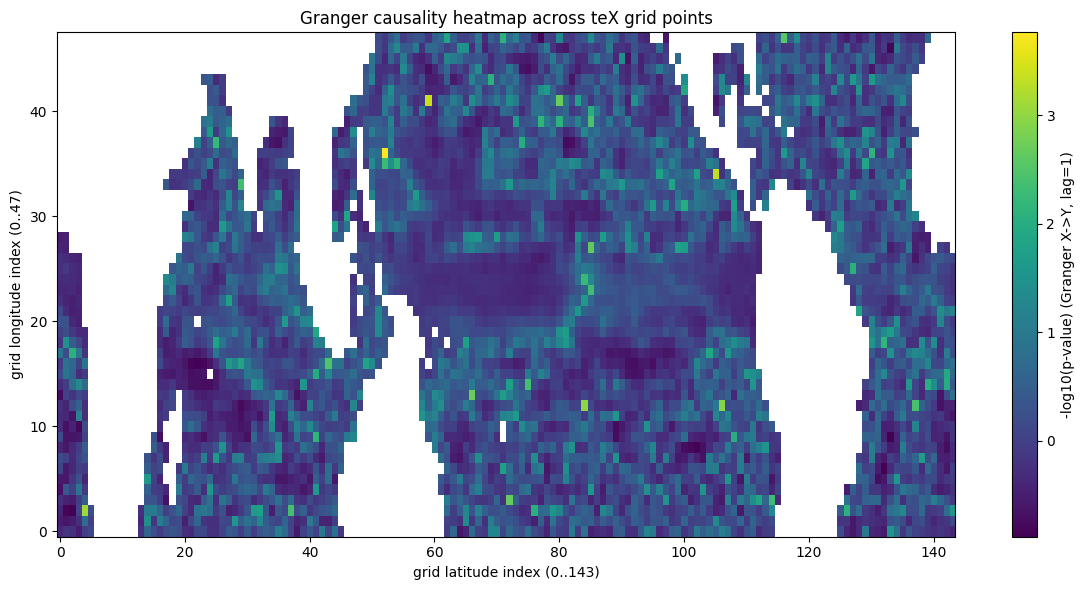

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

import matplotlib.pyplot as plt

n = 104
X = trX[:n]             # shape (31, 144, 48, 3)
Y = np.asarray(trY[:n], dtype=np.float64)  # shape (31,)

maxlag = 1
# pvals = np.full((144, 48), np.nan, dtype=np.float64)
# fstats = np.full((144, 48), np.nan, dtype=np.float64)
linear_gc_scores = np.full((144, 48), np.nan, dtype=np.float64)
for i in range(144):
    for j in range(48):
        x = X[:, i, j, :].mean(axis=1)  # combine 3 channels
        data = np.column_stack([Y, x])  # Y is target, x is driver
        try:
            test_result = grangercausalitytests(data, maxlag=maxlag, verbose=False)
            p_values = [test_result[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag + 1)]  # Extract p-values
            linear_gc_scores[i,j] = -np.log(min(p_values))  # Use -log(p) to rank (lower p → higher GC)
        except Exception:
            pass


causality_strength = -np.log10(linear_gc_scores)
#flip causality_strength.T upside down to match the original lat-lon orientation
#causality_strength = np.flipud(causality_strength)

causality_strength[np.isneginf(causality_strength)] = np.nan
causality_strength[np.isinf(causality_strength)] = np.nan

plt.figure(figsize=(12, 6))
plt.imshow(causality_strength.T, origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(label="-log10(p-value) (Granger X->Y, lag=1)")
plt.title("Granger causality heatmap across teX grid points")
plt.xlabel("grid latitude index (0..143)")
plt.ylabel("grid longitude index (0..47)")
plt.tight_layout()
plt.show()

In [ ]:
alpha = -np.log10(0.45) #65% CI
significance_mask = causality_strength >= alpha
np.save('significance_mask_SODA.npy', significance_mask)
# causality_strength[causality_strength < alpha] = 0
# causality_strength[causality_strength >= alpha] = 1
causality_mask = np.flipud(significance_mask.T)

In [ ]:

significance_mask = np.load('significance_mask_SODA.npy')
strong_idx = np.argwhere(significance_mask ==1)


In [ ]:
# number of True in significance_mask
num_significant = np.sum(significance_mask)
print("Number of significant locations:", num_significant)

Number of significant locations: 1602


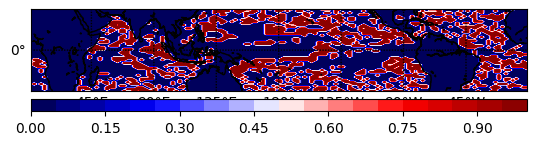

<Figure size 640x480 with 0 Axes>

In [ ]:
lat_sst=data3.variables['lat'][:]
lon_sst=data3.variables['lon'][:]
plot_map(lon_sst, lat_sst, causality_mask, 'granger_causality_map.png')

In [ ]:
test_result

{1: ({'ssr_ftest': (0.48906621286309027, 0.48596763640207363, 100.0, 1),
   'ssr_chi2test': (0.503738199248983, 0.4778621788972208, 1),
   'lrtest': (0.5025103941414386, 0.4783991487677546, 1),
   'params_ftest': (0.4890662128630986, 0.48596763640207363, 100.0, 1.0)},
   array([[0., 1., 0.]])])}

In [ ]:
linear_gc_scores

array([[2.19749515, 3.47756447, 2.57491068, ...,        nan,        nan,
               nan],
       [1.54772191, 3.95744573, 6.54778984, ...,        nan,        nan,
               nan],
       [1.63714645, 3.35080866, 7.70953808, ...,        nan,        nan,
               nan],
       ...,
       [1.42522447, 1.58506127, 0.93498005, ...,        nan,        nan,
               nan],
       [1.78720214, 1.4297846 , 0.16732188, ...,        nan,        nan,
               nan],
       [2.52832928, 0.74406113, 0.02649536, ...,        nan,        nan,
               nan]])

In [ ]:
causality_strength

array([[-0.34192792, -0.54127519, -0.41076217, ...,         nan,
                nan,         nan],
       [-0.18969293, -0.59741497, -0.81609473, ...,         nan,
                nan,         nan],
       [-0.21408753, -0.52514963, -0.88702836, ...,         nan,
                nan,         nan],
       ...,
       [-0.15388327, -0.20004606,  0.02919766, ...,         nan,
                nan,         nan],
       [-0.25217368, -0.15527062,  0.77644726, ...,         nan,
                nan,         nan],
       [-0.40283363,  0.12839138,  1.57683023, ...,         nan,
                nan,         nan]])

In [ ]:

feature_dataset=[]
for len in range(trX.shape[0]):
    feature_values=[]
    for ch in range(3):
        f = []
        for loc in strong_idx:
            
            f.append(trX[0,loc[0],loc[1],ch])
        feature_values.append(np.array(f))

    feature_dataset.append(np.array(feature_values))

    #print(np.array(f).shape)
feature_dataset=np.array(feature_dataset).swapaxes(1,2)
feature_dataset.shape
# add an additional axis to dim=1 in feature_dataset to make it compatible with CNN input
#feature_dataset = feature_dataset[:, np.newaxis, :, :]
feature_dataset.shape

(6390, 661, 3)

In [ ]:
feature_dataset
#check if feature_dataset contains any NaN values
np.isnan(feature_dataset).any()

False

In [ ]:
feature_dataset.shape

(6390, 661, 3)

In [ ]:
fine_tune=keras.models.load_model('Sample_Model.keras')

fine_tune.load_weights('00000600.weights.h5')

from scipy.stats import pearsonr

prediction=fine_tune.predict(trainX[:104])
prediction=prediction.reshape(104,)

trY=trainY[:104].reshape(104,)
corr, p = pearsonr(prediction, trY) 
print('weight', i+1)
print('corr', corr)
print('p value', p)
print('STD', np.std(prediction))

W0000 00:00:1773913422.285145 3177494 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
weight 31
corr -0.09624328051711621
p value 0.33110596004926435
STD 0.29654464


In [ ]:
prediction.shape

(104,)

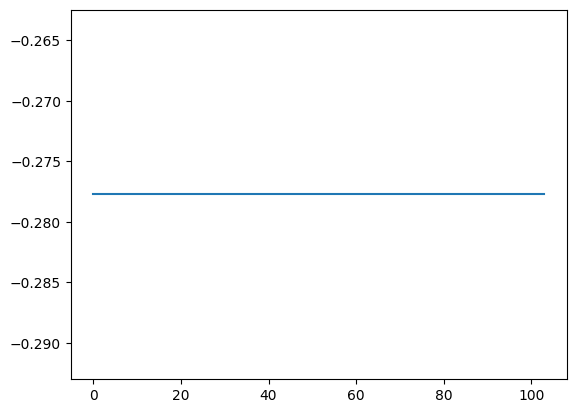

In [ ]:
plt.plot(prediction)

In [ ]:
feature_dataset.std()

17.511612

In [ ]:
feature_dataset_teX.std()

10.365428157291614

In [ ]:
prediction

array([0.00757123, 0.00757123, 0.00757123, 0.00757123, 0.00757123,
       0.00757123, 0.00757123, 0.00757123, 0.00757123, 0.00757123,
       0.00757123, 0.00757123, 0.00757123, 0.00757123, 0.00757123,
       0.00757123, 0.00757123, 0.00757123, 0.00757123, 0.00757123,
       0.00757123, 0.00757123, 0.00757123, 0.00757123, 0.00757123,
       0.00757123, 0.00757123, 0.00757123, 0.00757123, 0.00757123,
       0.00757123], dtype=float32)

In [ ]:
teY.shape

(31,)

In [ ]:
# Selecting the best base model
###############################################################################

fine_tune=keras.models.load_model('Sample_Model.keras')

for i in range(9):
  fine_tune.load_weights('00000'+str(i+1)+'00.weights.h5')

  from scipy.stats import pearsonr

  prediction=fine_tune.predict(teX*mask3)
  prediction=prediction.reshape(31,)

  teY=teY.reshape(31,)
  corr, p = pearsonr(prediction, teY) 
  print('weight', i+1)
  print('corr', corr)
  print('p value', p)
  print('STD', np.std(prediction))

# fine_tune.load_weights('00001000.weights.h5')

# from scipy.stats import pearsonr

# prediction=fine_tune.predict(teX)
# prediction=prediction.reshape(31,)

# teY=teY.reshape(31,)
# corr, p = pearsonr(prediction, teY) 
# print('weight', 10)
# print('corr', corr)
# print('p value', p)
# print('STD', np.std(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
weight 1
corr 0.05863677781910887
p value 0.7540305769602833
STD 0.08548859
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
weight 2
corr 0.1555814602449443
p value 0.4032955177917519
STD 0.11536635
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
weight 3
corr 0.11163794231560444
p value 0.5499036225065719
STD 0.14824401
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
weight 4
corr 0.17440367270668883
p value 0.34806294329796045
STD 0.20225704
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
weight 5
corr 0.05249284526938227
p value 0.779131842610468
STD 0.23974407
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
weight 6
corr 0.059935242907548474
p value 0.7487560716007129
STD 0.29856887
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
weight 7
corr 0.044316365988597874
p value 0.8128744238596898
STD 0.3361943
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
weight 8
corr 0.0481401914903987
p value 0.7970494037048708
STD 0.37231815
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
weight 9
corr -0.015507474628232761
p value 0.9340

In [ ]:
# Fine tuning the best base model
###############################################################################

fine_tune=keras.models.load_model('Sample_Model.keras')
fine_tune.load_weights('00000400.weights.h5')

opt=Adam(learning_rate=0.000005)

fine_tune.compile(optimizer=opt, loss='mean_squared_error')
model_checkpoint_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, verbose=1,
                                                              mode='min', restore_best_weights=True)

fine_tune.fit(trainX, trainY, epochs=60, batch_size=20)


Epoch 1/60
1/6 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - loss: 0.4920

E0000 00:00:1774356590.120395 3547099 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/sequential_1/leaky_re_lu_2_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/sequential_1/conv2d_2_1/BiasAdd'.


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.5509
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.5280
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7333
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.5772
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.5204
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.6399
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5663
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.5945
Epoch 9/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.5641
Epoch 10/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.6346
Epoch 11/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5703
Epoch 12/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.6530
Epoch 13/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.5514
Epoch 14/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5788
Epoch 15/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.5861
Epoch 16/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/

In [ ]:
# Saving the final CNN model
################################################################################

fine_tune.save_weights('fine_tune.weights.h5')

In [ ]:
teX_masked= teX * mask3  # zeros out non-significant grid cells across channels

In [14]:
# Validation of the FInal CNN model
################################################################################

fine_tune.load_weights('fine_tune.weights.h5')

prediction=fine_tune.predict(teX_masked)
prediction=prediction.reshape(31,)

teY=teY.reshape(31,)
corr, p = pearsonr(prediction, teY) 

print('corr', corr)
print('p value', p)
print('STD', np.std(prediction))

NameError: name 'fine_tune' is not defined

No granger causality weight matrix (causality_strength or linear_gc_scores) found.


In [37]:
teX.shape

(31, 144, 48, 3)

In [34]:
lat_sst=data3.variables['lat'][:]
lon_sst=data3.variables['lon'][:]

In [47]:
trainX.shape

(104, 144, 48, 3)

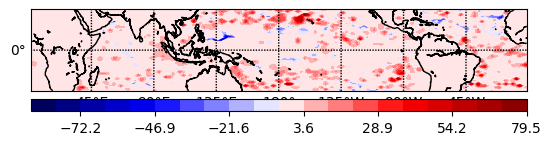

<Figure size 640x480 with 0 Axes>

In [51]:
plot_map(lon_sst, lat_sst, np.flipud(trainX[0,:,:,1].T), 'granger_causality_map.png')

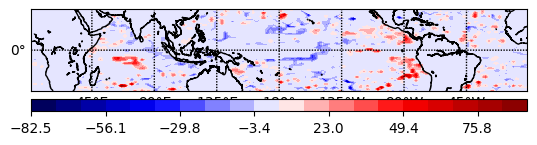

<Figure size 640x480 with 0 Axes>

In [56]:
plot_map(lon_sst, lat_sst, np.flipud(teX_masked[3,:,:,2].T), 'granger_causality_map.png')